In [15]:
from pprint import pprint as pp
import scene_generation
import data_loader
import config
import os
import snr
from IPython.display import Audio
import shutil

import numpy as np

Events selection: Specific events are chosen from the audible ontology based on their acoustic impulse nature.

## Datasets

#### Impulse Sounds:
- ESC50
- Nonspeech7k
- IDMTtraffic
- ReaLISED
- VocalSound

#### Backgrounds

- Dcase2018
- VehicleInteriorSound
- Cas2023
- CochlScene
- Arte

In [16]:
frg = data_loader.ForegroundLoader()
frg.pdf_metadata

ESC50: load metadata file /home/ids/pstamatiadis/IS3/data/datasets/data_preprocessed/esc50_only_impulses/ESC-50-master/metadata.csv
Nonspeech7k: load metadata file /home/ids/pstamatiadis/IS3/data/datasets/data_preprocessed/nonspeech7k_only_impulses/metadata.csv
ReaLISED: load metadata file /home/ids/pstamatiadis/IS3/data/datasets/data_preprocessed/realised_only_impulses/metadata.csv
VocalSound: load metadata file /home/ids/pstamatiadis/IS3/data/datasets/data_preprocessed/vocalsound_only_impulses/metadata.csv


,file_path,n_channels,sampling_rate,duration,dataset_label,impulse_type,dataset,std_label
0,/home/ids/pstamatiadis/IS3/data/datasets/data_...,1,44100,4.776054,clock_tick,natural,ESC50,clock_tick
1,/home/ids/pstamatiadis/IS3/data/datasets/data_...,1,44100,0.405034,sneezing,natural,ESC50,human_sound
2,/home/ids/pstamatiadis/IS3/data/datasets/data_...,1,32000,4.000000,breath,natural,Nonspeech7k,human_sound
3,/home/ids/pstamatiadis/IS3/data/datasets/data_...,1,32000,3.540000,cough,natural,Nonspeech7k,human_sound
4,/home/ids/pstamatiadis/IS3/data/datasets/data_...,1,32000,3.930000,crying,natural,Nonspeech7k,human_sound
5,/home/ids/pstamatiadis/IS3/data/datasets/data_...,1,32000,4.000000,screaming,natural,Nonspeech7k,human_sound
6,/home/ids/pstamatiadis/IS3/data/datasets/data_...,1,32000,3.420000,sneeze,natural,Nonspeech7k,human_sound
7,/home/ids/pstamatiadis/IS3/data/datasets/data_...,1,44100,2.524218,breath,natural,Nonspeech7k,human_sound
8,/home/ids/pstamatiadis/IS3/data/datasets/data_...,1,44100,0.336190,object falling,natural,ReaLISED,object_fall
9,/home/ids/pstamatiadis/IS3/data/datasets/data_...,1,44100,0.152109,switch,natural,ReaLISED,switch_on_or_off


In [17]:
bkg = data_loader.BackgroundLoader()
bkg.pdf_metadata

Arte: load metadata file /home/ids/pstamatiadis/IS3/data/datasets/data_preprocessed/arte_impulse_free/metadata.csv
CochlScene: load metadata file /home/ids/pstamatiadis/IS3/data/datasets/data_preprocessed/cochlscene_impulse_free/metadata.csv
Cas2023: load metadata file /home/ids/pstamatiadis/IS3/data/datasets/data_preprocessed/cas2023_impulse_free/metadata.csv
VehicleInteriorSound: load metadata file /home/ids/pstamatiadis/IS3/data/datasets/data_preprocessed/visc_son_impulse_free/metadata.csv
Dcase2018: load metadata file /home/ids/pstamatiadis/IS3/data/datasets/data_preprocessed/dcase2018_impulse_free/TUT-urban-acoustic-scenes-2018-development/metadata.csv


,file_path,n_channels,sampling_rate,duration,dataset_label,background_type,dataset,std_label
0,/home/ids/pstamatiadis/IS3/data/datasets/data_...,2,44100,125.551995,library,natural,Arte,library
1,/home/ids/pstamatiadis/IS3/data/datasets/data_...,2,44100,51.901973,office,natural,Arte,office
2,/home/ids/pstamatiadis/IS3/data/datasets/data_...,2,44100,142.685986,church,natural,Arte,church
3,/home/ids/pstamatiadis/IS3/data/datasets/data_...,2,44100,61.929977,living_room,natural,Arte,living_room
4,/home/ids/pstamatiadis/IS3/data/datasets/data_...,2,44100,109.167982,cafe,natural,Arte,cafe_or_restaurant
5,/home/ids/pstamatiadis/IS3/data/datasets/data_...,2,44100,54.639977,dinner_party,natural,Arte,home
6,/home/ids/pstamatiadis/IS3/data/datasets/data_...,2,44100,132.843991,street_balcony,natural,Arte,street_balcony
7,/home/ids/pstamatiadis/IS3/data/datasets/data_...,2,44100,148.043991,train_station,natural,Arte,train_station
8,/home/ids/pstamatiadis/IS3/data/datasets/data_...,2,44100,84.283991,food_court,natural,Arte,cafe_or_restaurant
9,/home/ids/pstamatiadis/IS3/data/datasets/data_...,1,48000,8.918000,Restaurant,natural,Cas2023,cafe_or_restaurant


In [12]:
# Generate a single scene
output_dir = os.path.join(os.getcwd(), 'test_scene')

if os.path.isdir(output_dir):
  shutil.rmtree(output_dir)

sr = 44100
duration = 5
n_backgrounds = 1
n_impulses = 3  # np.random.randint(1, 5)
print(f"Number of impulses: {n_impulses}")
impulse_max_duration = 2


# Define the scene
s = scene_generation.Scene(
    audio_output_dir=output_dir,
    json_output_dir=output_dir,
    backgrounds_pdf=bkg.pdf_metadata,
    impulses_pdf=frg.pdf_metadata,
    sr=sr,
    duration=duration,
    impulse_max_duration=impulse_max_duration,
    n_backgrounds=n_backgrounds,
    n_impulses=n_impulses,
    background_scene=None,
    impulse_type=None,
)

# Create mixture
s.generate_scene()

# Let's check the scene's metadata
pp(s.metadata)

Number of impulses: 3
{'audio_root_dir': '/home/ids/pstamatiadis/IS3/data/scene_generation/test_scene',
 'background_1': {'duration': 5.0,
                  'file_path': '/home/ids/pstamatiadis/IS3/data/datasets/data_preprocessed/dcase2018_impulse_free/TUT-urban-acoustic-scenes-2018-development/audio/metro-helsinki-222-6739-a.wav',
                  'mono': True,
                  'offset': 64976,
                  'sr': 44100,
                  'std_label': 'train_interior'},
 'background_audio_path': '/home/ids/pstamatiadis/IS3/data/scene_generation/test_scene/background.wav',
 'background_scene': 'train_interior',
 'dba_normalization_coeff': 36418.29729272156,
 'dba_target': 77.27482555422903,
 'has_impulses': True,
 'impulse_1': {'augmentation_params': {'PitchShift': {'are_parameters_frozen': False,
                                                      'max_semitones': 4,
                                                      'min_semitones': -4,
                                    

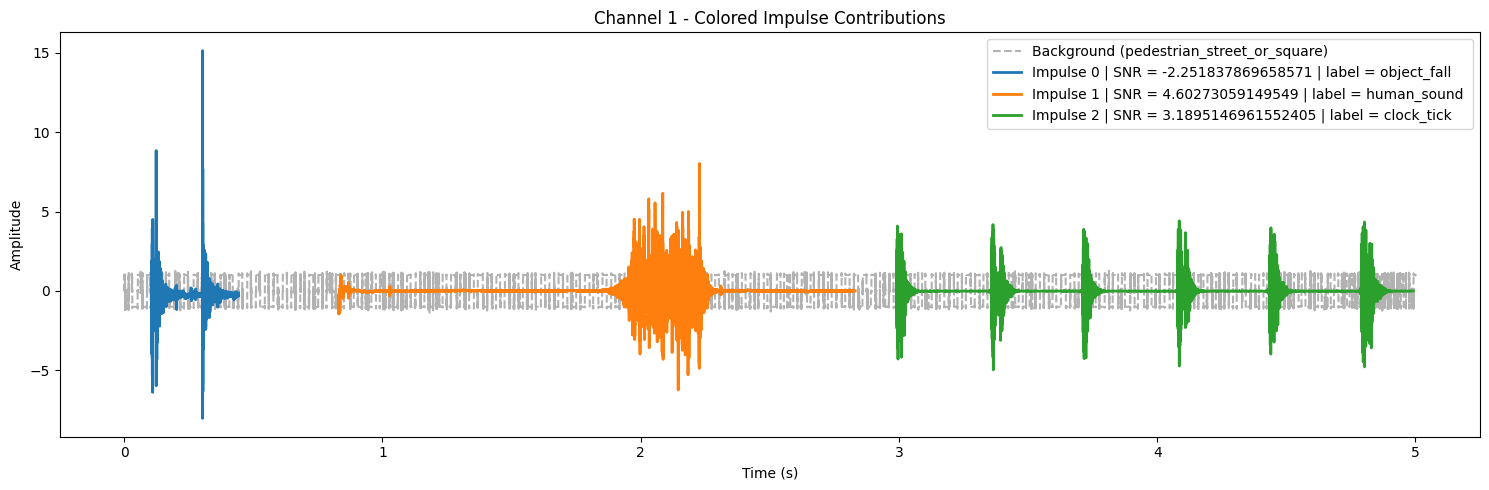

In [8]:
# Let's check the mixture's graph
s.plot_mixture()

In [9]:
# Check the audio mixture
display(Audio(s.mixture.flatten(), rate=s.sr))

In [10]:
display(Audio(np.sum(s.impulse_mixture, axis=0).flatten(), rate=s.sr))

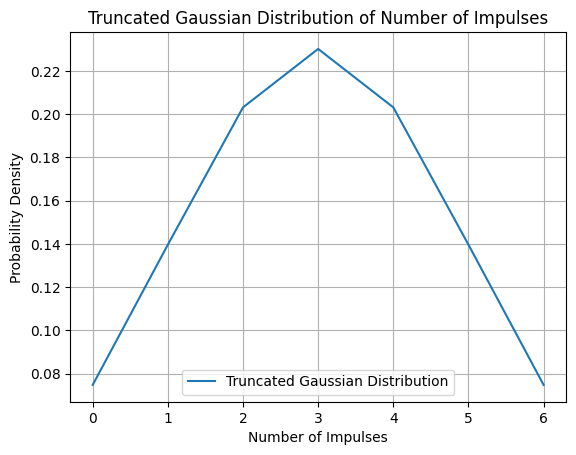

In [11]:
import matplotlib.pyplot as plt
import utils

max_n_impulses = 5

n_impulses_distrib = utils.initialize_truncated_gaussian(
    mean=3, std=2, min_val=0, max_val=max_n_impulses + 1)


x = np.arange(0, max_n_impulses + 2)
y = n_impulses_distrib.pdf(x)

plt.plot(x, y, label='Truncated Gaussian Distribution')
plt.xlabel('Number of Impulses')
plt.ylabel('Probability Density')
plt.title('Truncated Gaussian Distribution of Number of Impulses')
plt.legend()
plt.grid(True)
plt.show()